# Signal Processing Basics

> Adapted from [DartBrains](https://dartbrains.org/) by Luke Chang (© Luke Chang, supported by NSF CAREER Award 1848370), used under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/). **Changes made:** trimmed to the exercise sections, setup code reduced to the cells the exercises depend on, display-only calls removed. Exercise solutions are my own work. This notebook is therefore also distributed under CC BY-SA 4.0. No endorsement by the original author is implied.


In [ ]:
%matplotlib inline
pass
import numpy as np
import matplotlib.pyplot as plt
a = np.random.randint(1, 10, 20)
b = np.random.randint(1, 10, 20)

In [ ]:
from ipywidgets import interact, FloatSlider
from numpy import sin, pi, arange, real, imag

def plot_oscillation(amplitude=5, frequency=5, theta=1):
    sampling_frequency = 500
    time = arange(-1, 1 + 1 / sampling_frequency, 1 / sampling_frequency)
    simulation = amplitude * sin(2 * pi * frequency * time + theta)
    z = np.exp(1j * (2 * pi * frequency * time + theta))
    fig = plt.figure(figsize=(20, 4))
    gs = plt.GridSpec(1, 6, left=0.05, right=0.48, wspace=0.05)
    ax1 = fig.add_subplot(gs[0, :4])
    ax1.plot(time, simulation, linewidth=2)
    ax1.set_ylabel('Amplitude', fontsize=18)
    ax1.set_xlabel('Time', fontsize=18)
    ax2 = fig.add_subplot(gs[0, 5:], polar=True)
    ax2.plot(real(simulation), imag(simulation))
    plt.tight_layout()
interact(plot_oscillation, amplitude=FloatSlider(value=5, min=0, max=10, step=0.5), frequency=FloatSlider(value=5, min=0, max=10, step=0.5), theta=FloatSlider(value=0, min=-5, max=5, step=0.5))

In [ ]:
sampling_freq = 500
freq = [3, 10, 5, 15, 35]
amplitude = [5, 15, 10, 5, 7]
phases = pi * np.array([1 / 7, 1 / 8, 1, 1 / 2, -1 / 4])
time = arange(-1, 1 + 1 / sampling_freq, 1 / sampling_freq)
sine_waves = []
for i, f in enumerate(freq):
    sine_waves.append(amplitude[i] * sin(2 * pi * f * time + phases[i]))
sine_waves = np.array(sine_waves)
noise = 5 * np.random.randn(sine_waves.shape[1])
signal = np.sum(sine_waves, axis=0) + noise

In [ ]:
from scipy.signal import butter, filtfilt, freqz
filter_order = 3
frequency_cutoff = 25
sampling_frequency = 500
b, a = butter(filter_order, frequency_cutoff, btype='high', output='ba', fs=sampling_frequency)

def rad_sample_to_hz(x, fs):
    return x * fs / (2 * np.pi)

def plot_filter(b, a, fs):
    plt.figure(figsize=(20, 5))
    w, h = freqz(b, a, worN=512 * 2, whole=False)
    plt.plot(rad_sample_to_hz(w, fs), abs(h), linewidth=3)
    plt.ylabel('Gain', fontsize=18)
    plt.xlabel('Frequency', fontsize=18)

In [ ]:
from scipy.signal import butter, filtfilt
filter_order = 2
frequency_cutoff = 10
sampling_frequency = 500
b, a = butter(filter_order, frequency_cutoff, btype='low', output='ba', fs=sampling_frequency)
filtered = filtfilt(b, a, signal)

## Exercises

### Exercise 1. Create a simulated time series with 7 different frequencies with noise

Text(0.5, 0, 'Time')

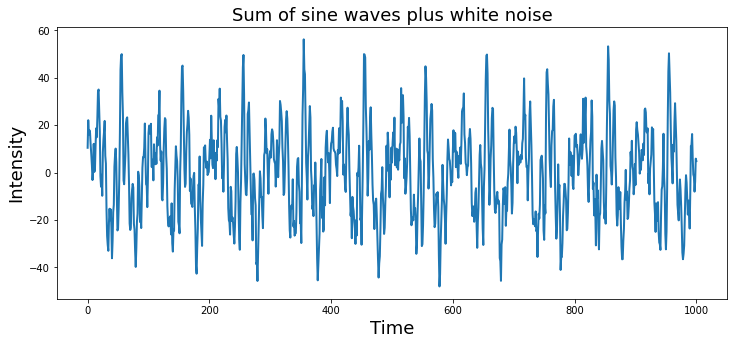

In [40]:
sampling_freq = 500

freq = [5, 10 ,15, 35, 40, 50, 55]
amplitude = [5, 15, 10, 5, 7, 9, 12]
phases = pi*np.array([1/7, 1/8, 1, 1/2, -1/4, -1/2, 1/3])

time = arange(-1, 1 + 1/sampling_freq, 1/sampling_freq) 

sine_waves = []
for i,f in enumerate(freq):
    sine_waves.append(amplitude[i] * sin(2*pi*f*time + phases[i]))
sine_waves = np.array(sine_waves)


noise = 5 * np.random.randn(sine_waves.shape[1])
signal = np.sum(sine_waves,axis=0) + noise

plt.figure(figsize=(12,5))
plt.plot( signal, linewidth=2)
plt.title("Sum of sine waves plus white noise", fontsize=18)
plt.ylabel('Intensity', fontsize=18)
plt.xlabel('Time', fontsize=18)

### Exercise 2. Show that you can identify each signal using a FFT

Text(0.5, 1.0, 'Reconstructed Time Series Signal')

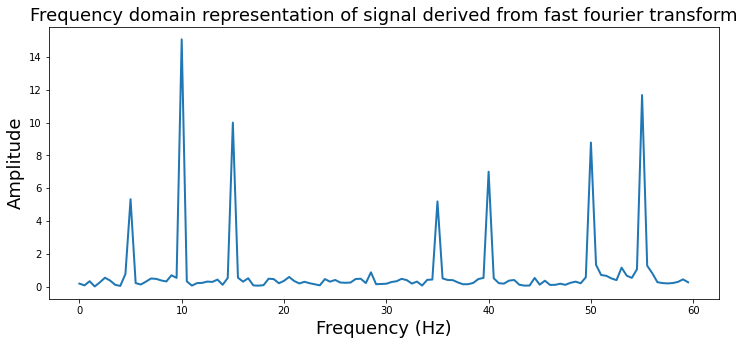

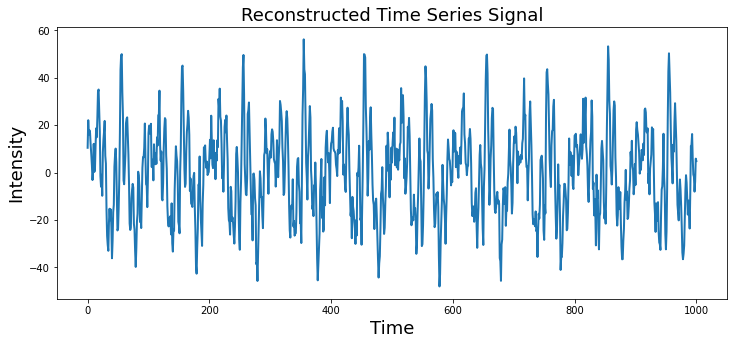

In [41]:
from numpy.fft import fft, ifft, fftfreq

fourier_fft = fft(signal)

plt.figure(figsize=(12,5))
plt.plot((np.arange(0,120)/2), 2*np.abs(fourier_fft[0:120])/len(signal), linewidth=2)
plt.ylabel('Amplitude', fontsize=18)
plt.xlabel('Frequency (Hz)', fontsize=18)
plt.title('Frequency domain representation of signal derived from fast fourier transform', fontsize=18)

plt.figure(figsize=(12, 5))
plt.plot(ifft(fourier_fft), linewidth=2)
plt.ylabel('Intensity', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.title('Reconstructed Time Series Signal', fontsize=18)

### Exercise 3. Remove one frequency with a bandstop filter

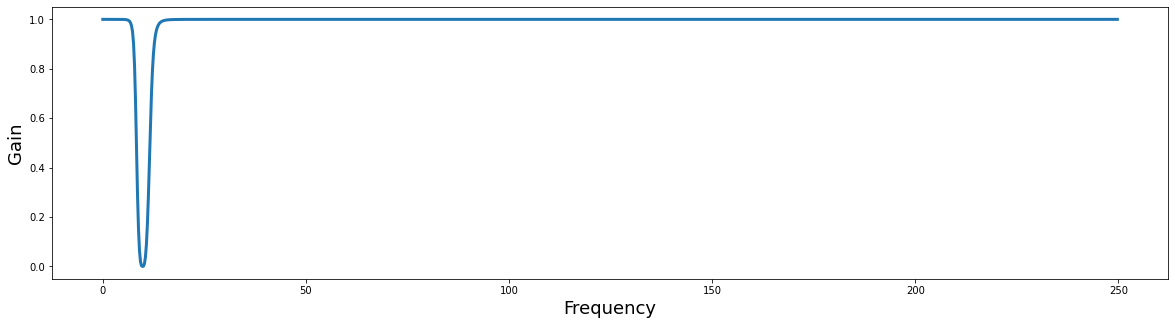

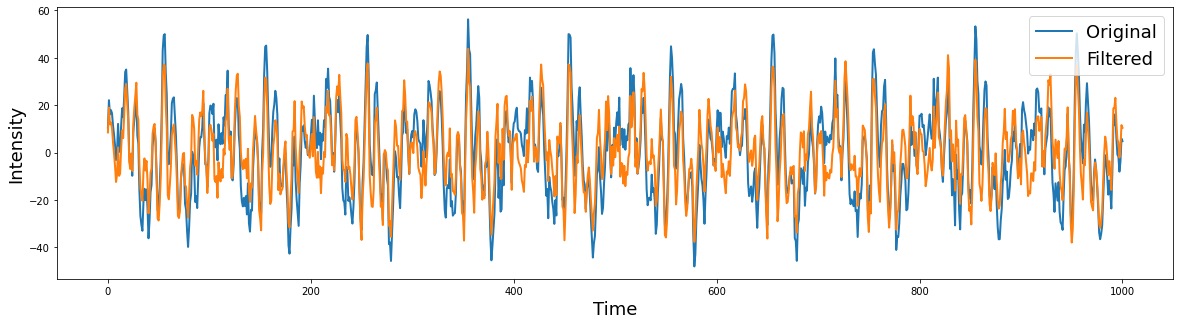

In [47]:
filter_order = 3
lowcut = 8
highcut = 12

# Create the filter
b,a = butter(filter_order, [lowcut, highcut], btype='bandstop', output='ba', fs=sampling_frequency)

# Plot the filter
plot_filter(b, a, sampling_frequency)

# Apply the filter
filtered = filtfilt(b, a, signal)

plt.figure(figsize=(20,5))
plt.plot(signal, linewidth=2)
plt.plot(filtered, linewidth=2)
plt.ylabel('Intensity', fontsize=18)
plt.xlabel('Time', fontsize=18)
plt.legend(['Original','Filtered'], fontsize=18)